<a href="https://colab.research.google.com/github/mohan342/project_Forex-Exchange-Rate-Volatility/blob/main/Forex_Exchange_Rate_Volatility.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install yfinance scikit-learn seaborn xgboost tensorflow

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor

In [ ]:
import yfinance as yf
import pandas as pd

df = yf.download("INR=X", period="5y", interval="1d")
df = df.reset_index()

print(df.columns)

keep_cols = [c for c in ['Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume'] if c in df.columns]
df = df[keep_cols]

df.head()

/tmp/ipykernel_986/2215522424.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("INR=X", period="5y", interval="1d")
[*********************100%***********************]  1 of 1 completed


MultiIndex([(  'Date',      ''),
            ( 'Close', 'INR=X'),
            (  'High', 'INR=X'),
            (   'Low', 'INR=X'),
            (  'Open', 'INR=X'),
            ('Volume', 'INR=X')],
           names=['Price', 'Ticker'])


Price,Date,Open,High,Low,Close,Volume
Ticker,,INR=X,INR=X,INR=X,INR=X,INR=X
0,2021-06-25,74.190300,74.390999,74.116798,74.190300,0
1,2021-06-28,74.212997,74.328300,74.062500,74.212997,0
2,2021-06-29,74.285599,74.337799,74.189003,74.285400,0
3,2021-06-30,74.287598,74.473000,74.105003,74.287598,0
4,2021-07-01,74.371101,74.628502,74.310997,74.371002,0


In [ ]:
df['Return'] = df['Close'].pct_change()
df['Volatility'] = df['Return'].rolling(window=14).std() * np.sqrt(14)
df = df.dropna().reset_index(drop=True)
df[['Date', 'Close', 'Return', 'Volatility']].head()

Price,Date,Close,Return,Volatility
Ticker,,INR=X,,
0,2021-07-15,74.469101,-0.002545,0.008657
1,2021-07-16,74.537003,0.000912,0.008681
2,2021-07-19,74.631798,0.001272,0.008711
3,2021-07-20,74.993401,0.004845,0.009793
4,2021-07-21,74.527000,-0.006219,0.011949


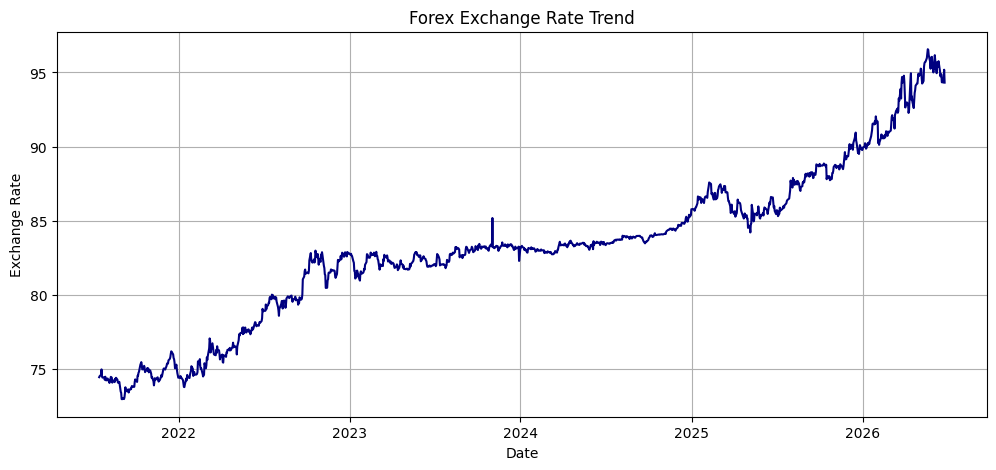

In [ ]:
plt.figure(figsize=(12,5))
plt.plot(df['Date'], df['Close'], color='navy')
plt.title('Forex Exchange Rate Trend')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.grid(True)
plt.show()

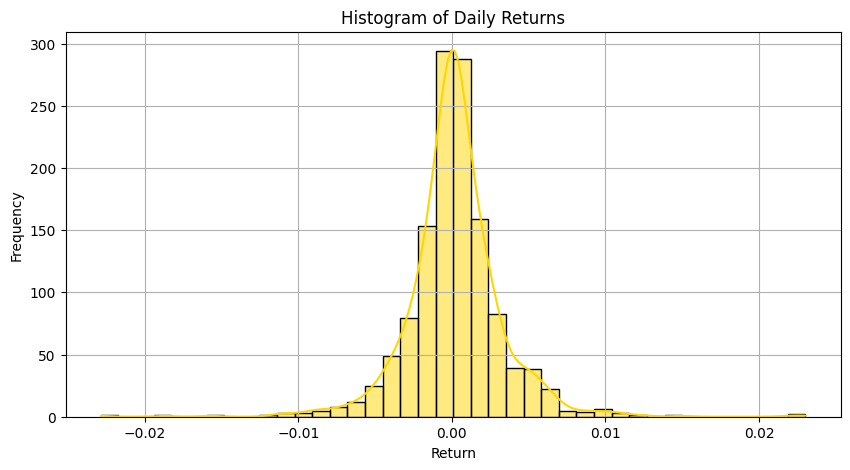

In [ ]:
plt.figure(figsize=(10,5))
sns.histplot(df['Return'], bins=40, kde=True, color='gold')
plt.title('Histogram of Daily Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

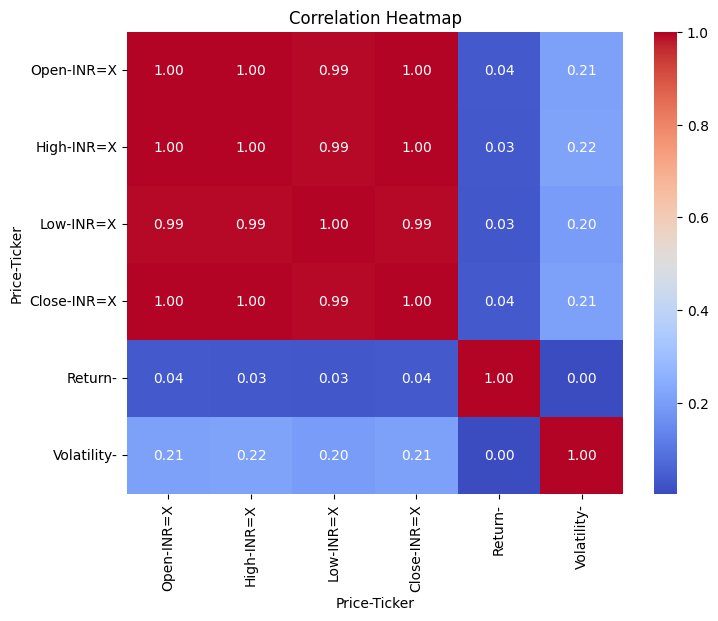

In [ ]:
plt.figure(figsize=(8,6))

cols = [c for c in ['Open', 'High', 'Low', 'Close', 'Return', 'Volatility'] if c in df.columns]
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

In [ ]:
print(df.columns.tolist())

[('Date', ''), ('Open', 'INR=X'), ('High', 'INR=X'), ('Low', 'INR=X'), ('Close', 'INR=X'), ('Volume', 'INR=X'), ('Return', ''), ('Volatility', '')]


In [ ]:
df['Lag_1'] = df['Close'].shift(1)
df['Lag_2'] = df['Close'].shift(2)
df['Lag_3'] = df['Close'].shift(3)
df['MA_7'] = df['Close'].rolling(7).mean()
df['MA_14'] = df['Close'].rolling(14).mean()
df = df.dropna().reset_index(drop=True)

In [ ]:
features = ['Open', 'High', 'Low', 'Close', 'Lag_1', 'Lag_2', 'Lag_3', 'MA_7', 'MA_14']
X = df[features]
y = df['Volatility']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append([
        name,
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred)),
        r2_score(y_test, pred)
    ])

results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2'])
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,0.006778,0.009536,-0.967119
1,Random Forest,0.005526,0.008035,-0.396741
2,XGBoost,0.005472,0.007939,-0.363579


In [ ]:
features = ['Open', 'High', 'Low', 'Close', 'Lag_1', 'Lag_2', 'Lag_3', 'MA_7', 'MA_14']
X = df[features]
y = df['Volatility']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=200, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append([
        name,
        mean_absolute_error(y_test, pred),
        np.sqrt(mean_squared_error(y_test, pred)),
        r2_score(y_test, pred)
    ])

results_df = pd.DataFrame(results, columns=['Model', 'MAE', 'RMSE', 'R2'])
results_df

,Model,MAE,RMSE,R2
0,Linear Regression,0.006778,0.009536,-0.967119
1,Random Forest,0.005526,0.008035,-0.396741
2,XGBoost,0.005472,0.007939,-0.363579


/tmp/ipykernel_986/2272609060.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='RMSE', palette='viridis')


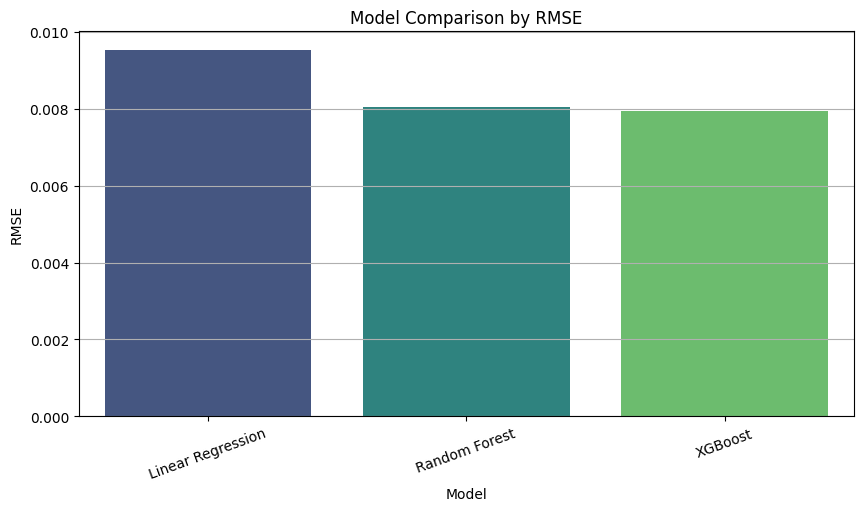

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(data=results_df, x='Model', y='RMSE', palette='viridis')
plt.title('Model Comparison by RMSE')
plt.xticks(rotation=20)
plt.grid(True, axis='y')
plt.show()

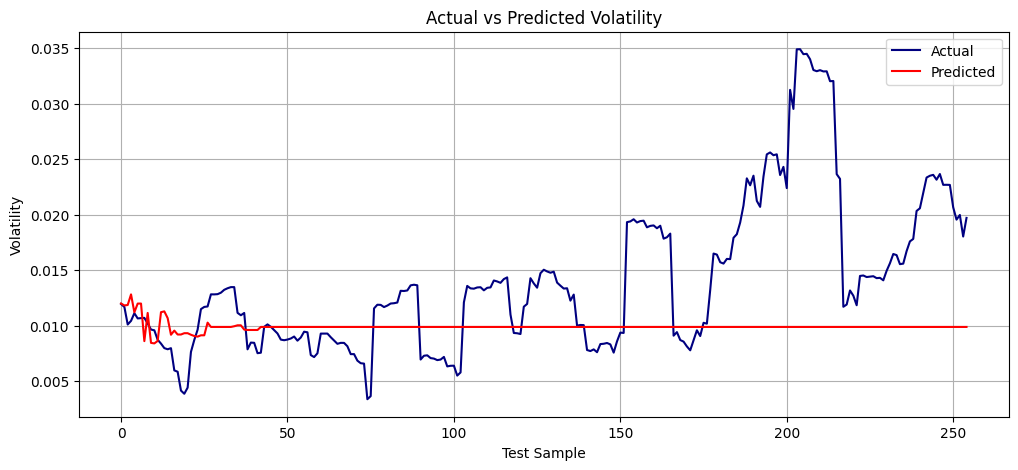

In [ ]:
best_model = XGBRegressor(n_estimators=200, learning_rate=0.05, random_state=42)
best_model.fit(X_train, y_train)
pred = best_model.predict(X_test)

plt.figure(figsize=(12,5))
plt.plot(y_test.values, label='Actual', color='navy')
plt.plot(pred, label='Predicted', color='red')
plt.title('Actual vs Predicted Volatility')
plt.xlabel('Test Sample')
plt.ylabel('Volatility')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

seq = df[['Close', 'Volatility']].values
X_seq, y_seq = [], []

for i in range(14, len(seq)):
    X_seq.append(seq[i-14:i, 0])
    y_seq.append(seq[i, 1])

X_seq = np.array(X_seq).reshape(-1, 14, 1)
y_seq = np.array(y_seq)

split = int(len(X_seq)*0.8)
X_train_s, X_test_s = X_seq[:split], X_seq[split:]
y_train_s, y_test_s = y_seq[:split], y_seq[split:]

lstm = Sequential([
    LSTM(50, input_shape=(14, 1)),
    Dense(1)
    ])
lstm.compile(optimizer='adam', loss='mse')
lstm.fit(X_train_s, y_train_s, epochs=10, batch_size=16, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 0.0999
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.6638e-04
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 1.0966e-04
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 7.3820e-05
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 4.9649e-05
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 3.7849e-05
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.2321e-05
Epoch 8/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 3.0674e-05
Epoch 9/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.0477e-05
Epoch 10/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 2.8701e-05
